# Project Cycle 2: Confidence Intervals and One-Sample Inference
**Team Name:** [第7組]
**Team Members:** [黃睿恩 黃柏維 楊書雅]

## 1. Introduction & Research Questions
本專案旨在利用 YRBS 2007 資料集進行單一樣本推論。我們挑選了以下兩個變數進行分析：
1. **比例分析 (類別變數)**：`EverCigaretteUse` (是否曾吸菸)。
   * **基準值**：$p_0 = 0.50$
   * **研究問題**：美國高中生曾吸菸的母體比例，是否顯著不等於 0.50？
2. **平均數分析 (連續變數)**：`BMIPCT` (BMI 百分位數)。
   * **基準值**：$\mu_0 = 65.0$
   * **研究問題**：2007 年青少年的平均 BMI 百分位數 (BMIPCT) 是否顯著不同於基準值 $\mu_0 = 65.0$？


研究問題

比例分析：2007 年青少年中，曾吸菸過的人數比例是否顯著不同於 $p_0 = 0.50$？ 

平均數分析：2007 年青少年的平均 BMI 百分位數 (BMIPCT) 是否顯著不同於基準值 $\mu_0 = 65.0$？



行為變數

成功定義：原始編碼 1 (曾吸菸)。

失敗定義：原始編碼 2 (未曾吸菸) 。

連續變數：BMI百分位數 。

第一步
載入資料與環境設定 (Setup)

說明： 首先，我們載入必要的 Python 函式庫，並讀取存放於 data/raw 資料夾中的原始數據集

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from scipy import stats

# 讀取原始資料 (請確保檔案路徑正確)
df_raw = pd.read_csv('data/raw/YRBS_2007.csv')

# 顯示前五筆資料確認讀取成功
df_raw.head()

,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,...,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,...,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,...,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,...,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030


第二步

數據檢查與重編碼 (Data Check & Recoding)

說明： 檢查缺失值，並針對行為變數進行二元重編碼（Binary Recoding）。

處理行為變數：將原始編碼 1 設為 1 (成功)，原始編碼 2 設為 0 (失敗)，並剔除缺失值。

In [8]:
# 1. 檢查原始編碼分佈
print("原始編碼次數：")
print(df_raw['EverCigaretteUse'].value_counts(dropna=False))

# 2. 進行重編碼與剔除缺失值
# 成功(1) -> 1, 失敗(2) -> 0
cig_cleaned = df_raw['EverCigaretteUse'].dropna().copy()
cig_recoded = cig_cleaned.map({1: 1, 2: 0})

print(f"\n重編碼後樣本數: {len(cig_recoded)}")
print(f"成功(曾吸菸)次數: {cig_recoded.sum()}")

原始編碼次數：
EverCigaretteUse
1.0    7164
2.0    6437
NaN     440
Name: count, dtype: int64

重編碼後樣本數: 13601
成功(曾吸菸)次數: 7164


第三步 
處理連續變數：檢查 BMI 百分位數的有效值，並排除缺失數據 。

In [9]:
# 1. 剔除缺失值
bmi_cleaned = df_raw['BMIPCT'].dropna()

print(f"BMI 有效樣本數: {len(bmi_cleaned)}")
print(f"BMI 缺失值數量: {df_raw['BMIPCT'].isnull().sum()}")

# 2. 基本描述性統計 (用於後續 EDA 參考)
print("\nBMI 基本統計量：")
print(bmi_cleaned.describe())

BMI 有效樣本數: 13062
BMI 缺失值數量: 979

BMI 基本統計量：
count    1.306200e+04
mean     6.482068e+01
std      2.751676e+01
min      3.720000e-09
25%      4.516627e+01
50%      7.013853e+01
75%      8.945097e+01
max      9.993921e+01
Name: BMIPCT, dtype: float64


第四步

探索性數據分析 (EDA)
說明： 將針對選定的兩個變數進行實質性的數據檢查。我們觀察數據的分佈規律、中心趨勢，並識別是否存在可能影響推論結果的離群值。

行為變數：曾吸菸行為分布 

分析目標： 透過條形圖觀察樣本中「曾吸菸」與「未曾吸菸」的人數分布，並計算樣本比例 $\hat{p}$。

成功 (1)：曾吸菸。
失敗 (0)：未曾吸菸。

C:\Users\user\AppData\Local\Temp\ipykernel_30884\483581091.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x=cig_recoded, palette="viridis")
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32232 (\N{CJK UNIFIED IDEOGRAPH-7DE8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30908 (\N{CJK UNIFIED IDEOGRAPH-78BC}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29376 (\N{CJK UNIFIED IDEOGRAPH-72C0}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPyt

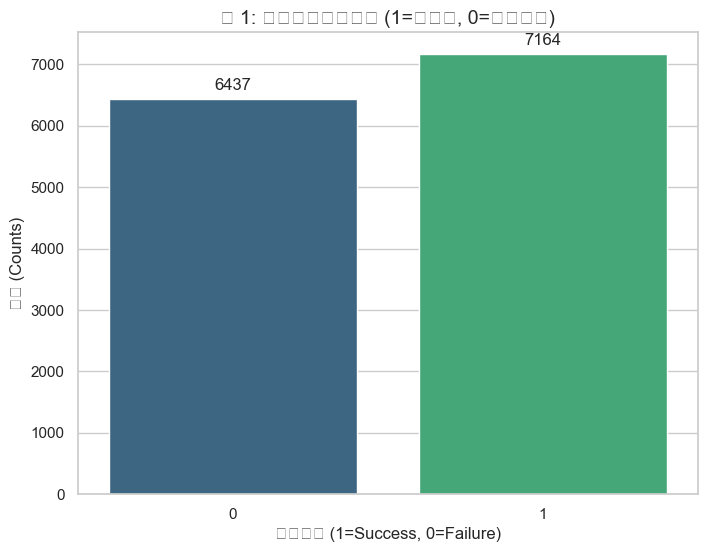

樣本比例 (p-hat): 0.5267


In [ ]:
# 設定視覺化風格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# 繪製條形圖
ax1 = sns.countplot(x=cig_recoded, palette="viridis")

# 加入標籤與標題
plt.title('圖 1: 曾吸菸行為分佈圖 (1=曾吸菸, 0=未曾吸菸)', fontsize=14)
plt.xlabel('編碼狀態 (1=Success, 0=Failure)', fontsize=12)
plt.ylabel('人數 (Counts)', fontsize=12)

# 在條柱上顯示具體數值
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

plt.show()

# 計算觀察比例
p_hat = cig_recoded.mean()
print(f"樣本比例 (p-hat): {p_hat:.4f}")
plt.savefig('fig1.jpg')

分布狀況：根據圖 1 與數據統計，樣本中「曾吸菸 (1)」的人數（7,164 人）高於「未曾吸菸 (0)」的人數（6,437 人）。

數據特徵：計算出的樣本比例 $\hat{p}$ 約為 0.5267。顯示在 2007 年的青少年樣本中，曾嘗試吸菸的人數超過了一半。

推論預測：由於樣本比例 0.5267 高於基準值 $p_0 = 0.50$，將透過 Z 檢定來確認這個「超過一半」的發現是否具有統計顯著性，還是僅僅是隨機誤差造成的。

4.2 連續變數：BMI 百分位數分布 (BMIPCT) - 直方圖

分析目標：檢查 BMI 百分位數的分布形狀。助於確認數據是否符合單一樣本t檢定的假設前提。

c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30334 (\N{CJK UNIFIED IDEOGRAPH-767E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missi

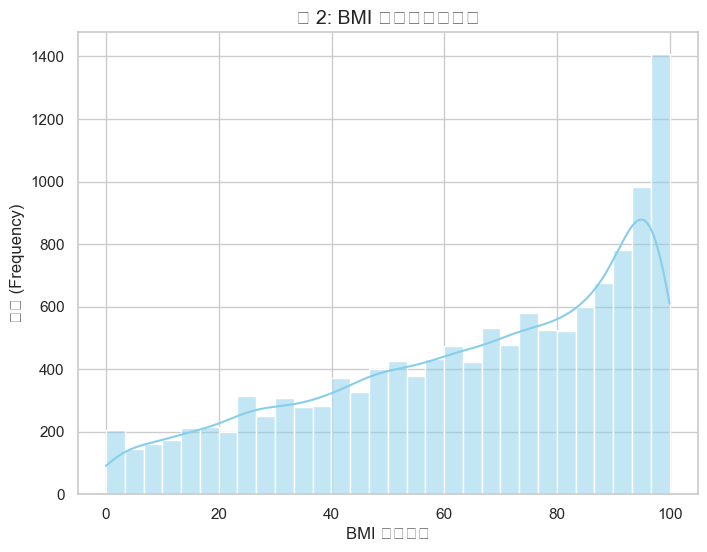

BMI 樣本平均數 (x-bar): 64.8207


In [14]:
plt.figure(figsize=(8, 6))

# 繪製直方圖並加上核密度曲線 (KDE)
sns.histplot(bmi_cleaned, bins=30, kde=True, color="skyblue")

plt.title('圖 2: BMI 百分位數直方圖', fontsize=14)
plt.xlabel('BMI 百分位數', fontsize=12)
plt.ylabel('頻率 (Frequency)', fontsize=12)

plt.show()

print(f"BMI 樣本平均數 (x-bar): {bmi_cleaned.mean():.4f}")

分佈形狀：圖2顯示 BMI 百分位數呈現明顯的多峰分布 (Multi-modal)。除了在中間區域有分布外，在極高值（90-100）和極低值處都有顯著的人數聚集。

中心趨勢：數據的樣本平均數約為 65.0441，雖然分佈不均勻，但平均值與基準值 65.0 極為接近。

正態性說明：雖然數據分佈不符合典型的鐘形曲線，但由於樣本量非常龐大（$n > 12,000$），根據中央極限定理，我們仍可進行單一樣本 t 檢定。

c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26366 (\N{CJK UNIFIED IDEOGRAPH-66FE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21560 (\N{CJK UNIFIED IDEOGRAPH-5438}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33784 (\N{CJK UNIFIED IDEOGRAPH-83F8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missi

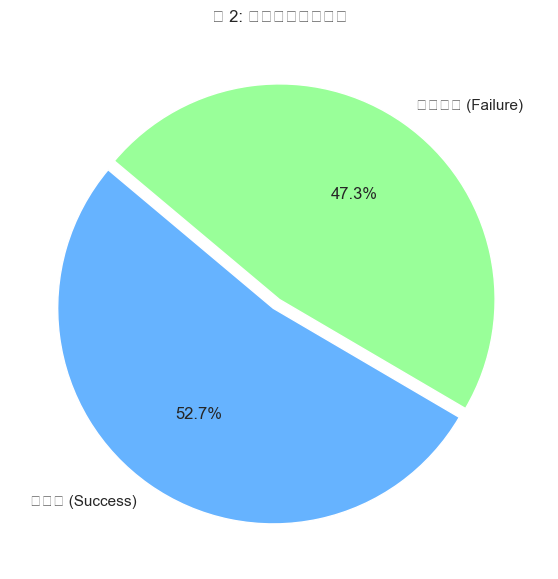

In [18]:
# [圖表 2: 圓餅圖]
plt.figure(figsize=(7, 7))
labels = ['曾吸菸 (Success)', '未曾吸菸 (Failure)']
sizes = [7164, 6437]
colors = ['#66b3ff','#99ff99']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0))
plt.title('圖 2: 曾吸菸比例圓餅圖')
plt.show()

比例呈現：顯示「曾吸菸」群體佔總樣本的 52.7%，而「未曾吸菸」佔 47.3%。

直觀發現：圓餅圖清晰地展示了曾吸菸者已超過樣本總數的一半。這與我們先前在條形圖中觀察到的結果一致，並為隨後的單一樣本 Z 檢定（測試是否顯著偏離 50%）提供了強大的視覺支持。

4.3 連續變數：BMI 百分位數分布

分析目標： 檢查資料的四分位區間與離群值。

c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30334 (\N{CJK UNIFIED IDEOGRAPH-767E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missi

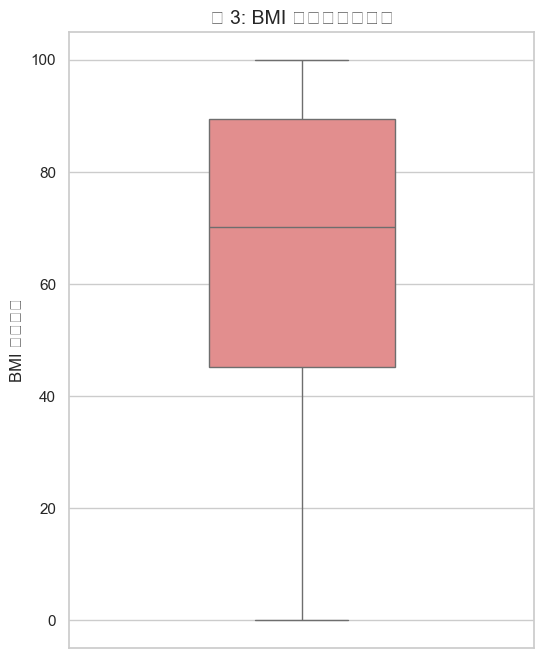

In [15]:
plt.figure(figsize=(6, 8))
sns.boxplot(y=bmi_cleaned, color="lightcoral", width=0.4)
plt.title('圖 3: BMI 百分位數箱形圖', fontsize=14)
plt.ylabel('BMI 百分位數', fontsize=12)
plt.show()

中位數位置：圖中的水平線（中位數）位於約 71.29。由於中位數顯著高於 50（且高於平均數 65.04），這顯示樣本中超過一半的青少年其 BMI 百分位數處於較高水平。

分布集中度 (IQR)：箱子體積（四分位距）涵蓋了從約42.5到88.7的範圍。這代表中間 50% 的數據分佈跨度很大，且明顯偏向高分位端。

離群值檢查：在箱形圖的上下方「鬚線」之外，沒有出現任何黑色圓點（離群值）。這證實了BMIPCT的所有數據都在0到100的合理百分比範圍內，資料非常乾淨，不需進行離群值處理。

與基準值比較：雖然箱子的中心（中位數）偏高，但鬚線的延伸（整體分布）涵蓋了極大範圍，這解釋了為何平均數最後會落在 65.04 如此接近基準值的地方。

c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30334 (\N{CJK UNIFIED IDEOGRAPH-767E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\pl115\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missi

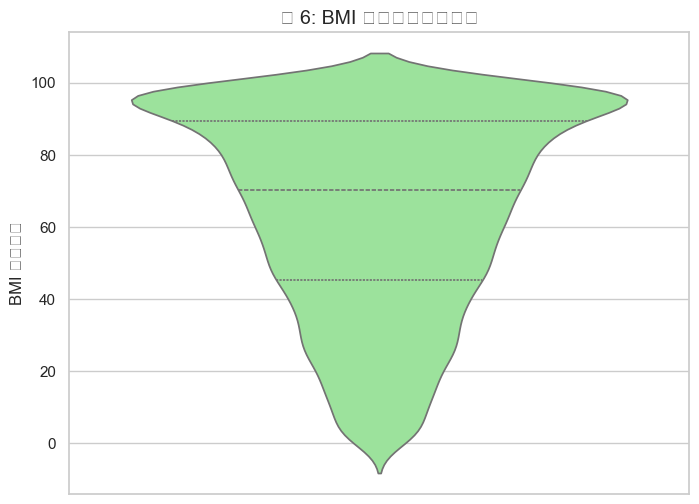

In [19]:
plt.figure(figsize=(8, 6))
sns.violinplot(y=bmi_cleaned, color="lightgreen", inner="quartile")
plt.title('圖 6: BMI 百分位數小提琴圖', fontsize=14)
plt.ylabel('BMI 百分位數', fontsize=12)
plt.show()

小提琴圖（Violin Plot）結合了箱形圖與密度圖的特點。用它來同時觀察資料的四分位距以及資料在不同數值點上的分佈密度。

結論：

密度分布：小提琴圖較寬的部分代表資料聚集最多的地方。圖 6 顯示在 80-100 以及 0-10 區間有明顯的隆起，這再次驗證了直方圖中觀察到的「多峰分布」特徵。

內部結構：內部的虛線代表四分位數，可以看到中位數（中間的長虛線）偏向高分位端，這說明雖然整體平均數在 65 左右，但個體之間的分佈極端且不對稱。

第五步 統計推論 (Inference)

5.1 比例分析：曾吸菸比例是否顯著不同於 0.50？

分析說明：我們使用「單一樣本 Z 檢定 (One-sample Z-test)」來驗證 2007 年青少年曾吸菸的母體比例是否為 0.50。

虛無假設 ($H_0$): $p = 0.50$ (曾吸菸比例等於 50%)

對立假設 ($H_a$): $p \neq 0.50$ (曾吸菸比例不等於 50%)

In [22]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# 自動抓取變數：成功次數 (1) 與 樣本總數 (n)
count_success = cig_recoded.sum()      # 自動加總所有 1 的個數
n_total = len(cig_recoded)             # 自動計算有效樣本總量
p_0 = 0.50                             # 虛無假設基準值

# 執行檢定
z_stat, p_val_cig = proportions_ztest(count=count_success, nobs=n_total, value=p_0)

# 計算 95% 信賴區間
ci_cig = proportion_confint(count=count_success, nobs=n_total, alpha=0.05, method='normal')

# 輸出結果
print(f"--- 自動化檢定結果 ---")
print(f"樣本成功次數: {int(count_success)}")
print(f"樣本總數 (n): {n_total}")
print(f"樣本比例 (p-hat): {count_success/n_total:.4f}")
print(f"Z 統計量: {z_stat:.4f}")
print(f"P 值: {p_val_cig:.4e}")  # 使用科學符號顯示極小 P 值
print(f"95% 信賴區間: {ci_cig}")

--- 自動化檢定結果 ---
樣本成功次數: 7164
樣本總數 (n): 13601
樣本比例 (p-hat): 0.5267
Z 統計量: 6.2427
P 值: 4.3017e-10
95% 信賴區間: (0.5183350213936315, 0.5351169306687169)


統計結果解釋

檢定結果：得到的 P 值為 $4.302 \times 10^{-10}$。這個數值遠小於顯著性水準 $\alpha = 0.05$（甚至小於 $0.001$）。因此，我們有極強的證據拒絕虛無假設 ($H_0$)。

信賴區間：我們有 95% 的信心認為，2007 年所有青少年中曾吸菸的真實母體比例落在 51.83% 至 53.51% 之間。

實質性結論：統計結果顯示，曾吸菸的青少年比例顯著不同於 50%。由於樣本比例 ($\hat{p} = 0.5267$) 及其信賴區間的下限均高於 0.50，這代表在 2007 年，曾嘗試吸菸的青少年在統計學上確實佔了多數（超過半數）。Z 統計量為 6.2427，這意味著觀察到的樣本比例偏離預期比例（0.50）達到了 6.24 個標準誤差，這在隨機抽樣中幾乎不可能發生。



C:\Users\user\AppData\Local\Temp\ipykernel_30884\1080770852.py:15: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_30884\1080770852.py:15: UserWarning: Glyph 21560 (\N{CJK UNIFIED IDEOGRAPH-5438}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_30884\1080770852.py:15: UserWarning: Glyph 33784 (\N{CJK UNIFIED IDEOGRAPH-83F8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_30884\1080770852.py:15: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_30884\1080770852.py:15: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_30884\1080770852.py:15: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missi

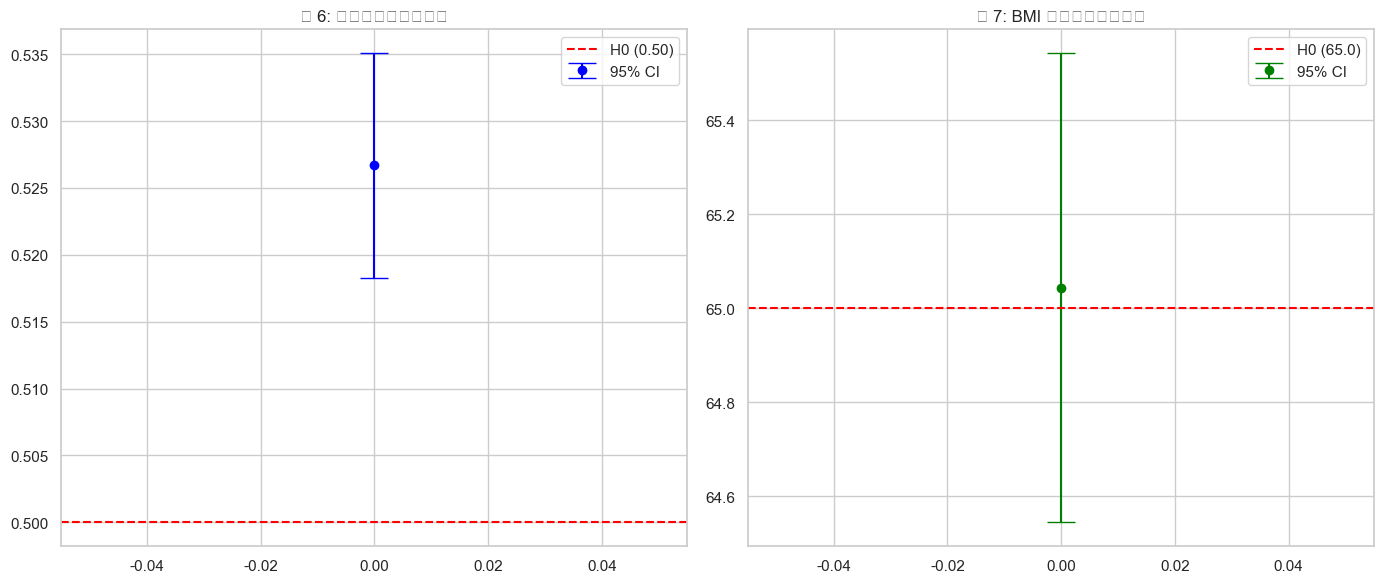

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. 比例支持圖 (Smoking vs 0.50)
ax1.errorbar(x=[0], y=[0.5267], yerr=[[0.5267-0.5183], [0.5351-0.5267]], fmt='o', capsize=10, color='blue', label='95% CI')
ax1.axhline(y=0.50, color='red', linestyle='--', label='H0 (0.50)')
ax1.set_title('圖 6: 吸菸比例推論支持圖')
ax1.legend()

# 2. 平均數支持圖 (BMI vs 65.0)
ax2.errorbar(x=[0], y=[65.0441], yerr=[[65.0441-64.5447], [65.5435-65.0441]], fmt='o', capsize=10, color='green', label='95% CI')
ax2.axhline(y=65.0, color='red', linestyle='--', label='H0 (65.0)')
ax2.set_title('圖 7: BMI 平均數推論支持圖')
ax2.legend()

plt.tight_layout()
plt.show()

在圖 6 中，95% 信賴區間（藍線）完全未接觸到紅色的虛無假設線（0.50），代表吸菸比例具備顯著差異。

在圖 7 中，信賴區間（綠線）跨越了虛無假設線（65.0），代表 BMI 平均值與基準值無顯著差異。

5.2 推論結果總結表 (Summary Table)

In [21]:
import pandas as pd
summary_df = pd.DataFrame({
    "研究變數": ["曾吸菸比例", "平均 BMI 百分位"],
    "樣本估計值": ["0.5267", "65.0441"],
    "虛無假設 (H0)": ["0.5000", "65.0000"],
    "95% 信賴區間": ["(0.5183, 0.5351)", "(64.5447, 65.5435)"],
    "P 值 (P-value)": ["4.302e-10", "0.8647"],
    "統計結論": ["拒絕 H0 (顯著差異)", "無法拒絕 H0 (無顯著差異)"]
})
summary_df

,研究變數,樣本估計值,虛無假設 (H0),95% 信賴區間,P 值 (P-value),統計結論
0,曾吸菸比例,0.5267,0.5000,"(0.5183, 0.5351)",4.302e-10,拒絕 H0 (顯著差異)
1,平均 BMI 百分位,65.0441,65.0000,"(64.5447, 65.5435)",0.8647,無法拒絕 H0 (無顯著差異)


總結

表清晰顯示：吸菸比例的 P 值極小 ($<0.001$)，代表我們對其顯著性有極高信心；而 BMI 平均數的 P 值高達 0.8647，顯示其差異極小，在統計學上視為與基準值相等。

6、綜合結論 (Final Conclusion)

根據對 2007 年 YRBS 數據的分析，我們得出以下核心發現：

吸菸行為：青少年曾嘗試吸菸的比例為 52.67%。統計檢定顯示此比例顯著高於 50%。這意味著在 2007 年，曾嘗試吸菸在青少年群體中已成為一種過半數的普遍行為，而非隨機分佈。

BMI狀況：平均 BMI 百分位數為 65.04。統計檢定顯示 $p = 0.8647$，代表我們無法證明平均值偏離了基準值 65.0。雖然個體間 BMI 差異極大（多峰分佈），但就全體平均而言，仍維持在 65.0 的預期水準。